# **Clasificación de Mutaciones en Secuencias de ADN Viral.**

El objetivo de este proyecto es clasificar secuencias de ADN viral como mutadas (`is_mutated = 1`) o no mutadas (`is_mutated = 0`). La metodología fue incremental: se comenzó con representaciones vectoriales simples y modelos individuales, y se aumentó la complejidad de forma justificada hasta llegar a la arquitectura final.


## **Contenido**

1. Análisis Exploratorio de Datos
2. Ingeniería de Features Biológicos
3. Representaciones Vectoriales (k-mers)
4. Visualización con t-SNE
5. Experimentación con Modelos Base y Stacking
6. Justificación del Número de Componentes PCA
7. Búsqueda del Umbral Óptimo
8. Experimento 1 — Pipeline con 1 Semilla
9. Mejor Modelo — 0.85 Public Score (3 Semillas)
10. Resultados y Generación de Submissions


---

##### **Nota: Si únicamente se desea generar predicciones sin re-entrenar los modelos, es posible ejecutar directamente la sección 10. Resultados y Generación de Submissions. Esa celda es completamente autocontenida: importa todas las librerías necesarias, define la clase DNAFeatureTransformer y la función predict_with_bundle, carga los pipelines entrenados desde models_f/ y genera los archivos de submission. No es necesario ejecutar ninguna celda anterior.**

---

In [26]:
import os, math, json, joblib, time, requests
import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


# Descarga de datos

In [27]:
try:
    from Utils.download_data import download_data
    download_data()
except:
    print("Descargar datos de forma manual en Data")

BASE_DATA  = "../Data"
TRAIN_CSV  = f"{BASE_DATA}/train.csv"
EVAL_CSV   = f"{BASE_DATA}/eval.csv"
MODELS_DIR = "models_f"
SEEDS      = [42, 7, 123]
N_FOLDS    = 5
N_SVD      = 80

os.makedirs(MODELS_DIR, exist_ok=True)
full_train  = pd.read_csv(TRAIN_CSV)
kaggle_eval = pd.read_csv(EVAL_CSV)
y_full      = full_train['is_mutated'].values
print(f"Train: {full_train.shape}  Eval: {kaggle_eval.shape}")


Descargar datos de forma manual en Data
Train: (46674, 4)  Eval: (5186, 3)


# 1. Análisis Exploratorio de Datos (EDA)

Se realiza un analisis exploratorio inicial para ver la distribucion de clases, longitudes y clases originales.


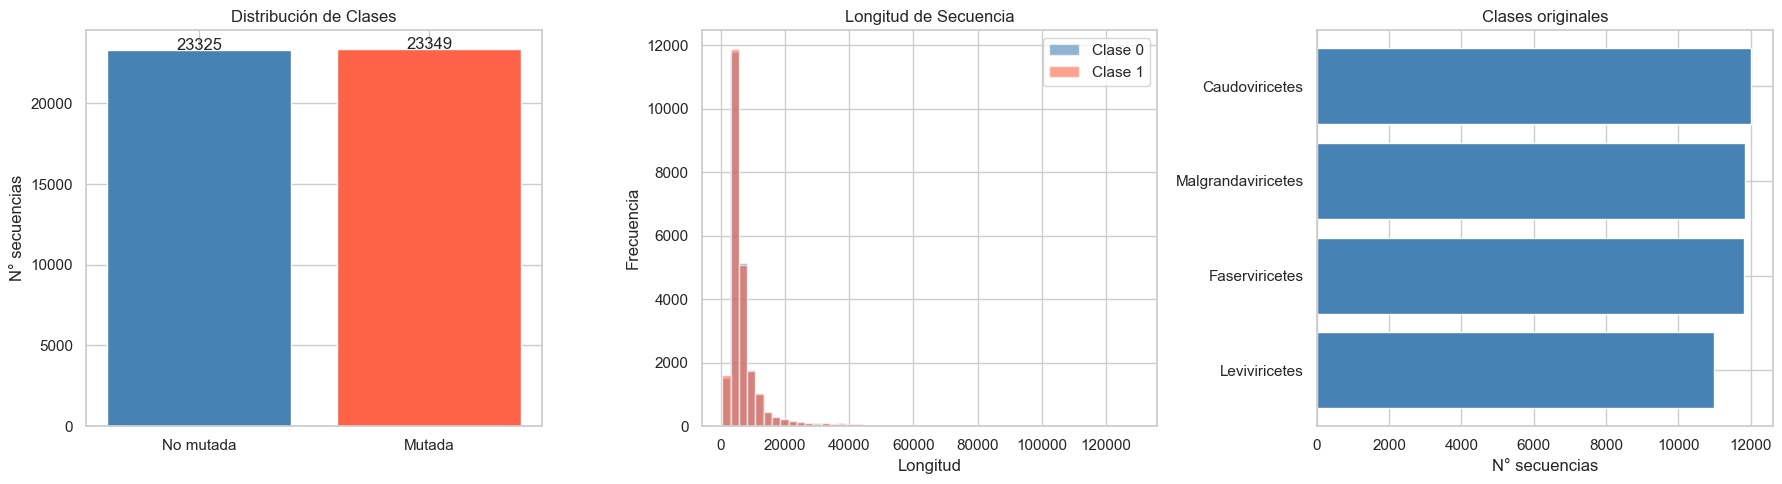

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))
full_train['seq_len'] = full_train['sequence'].str.len()



# Distribución de clases
counts = full_train['is_mutated'].value_counts().sort_index()
ax[0].bar(['No mutada','Mutada'], counts, color=['steelblue','tomato'])
for i,v in enumerate(counts): 
    ax[0].text(i, v, str(v), ha = 'center')
ax[0].set(title = 'Distribución de Clases', ylabel = 'N° secuencias')



# Longitud de secuencia por clase
for c,color in [(0,'steelblue'),(1,'tomato')]:
    ax[1].hist(full_train.loc[full_train.is_mutated==c,'seq_len'],
               bins=50, alpha=0.6, color=color, label=f'Clase {c}')
ax[1].set(title='Longitud de Secuencia', xlabel='Longitud', ylabel = 'Frecuencia')
ax[1].legend()



# Clases virales
top = full_train['original_label'].value_counts().head(15)
ax[2].barh(top.index[::-1], top.values[::-1], color='steelblue')
ax[2].set(title='Clases originales', xlabel='N° secuencias')

plt.tight_layout()
plt.show()

# 2. Ingeniería de Features

Durante la experimentación inicial con representaciones textuales de las secuencias, se observó que los modelos tenían dificultades para capturar patrones discriminativos que permitieran diferenciar adecuadamente entre secuencias mutadas y no mutadas.

Por esta razón, se decidió complementar la representación con 11 nuevas features basadas en propiedades biológicas conocidas de las secuencias. Estas características adicionales se muestran en la siguiente tabla.

| # | Feature | Descripción |
|---|---------|-------------|
| 1 | `longitud` | Número de caracteres en la secuencia |
| 2 | [`contenido_gc`](https://www.pnas.org/doi/10.1073/pnas.48.4.582) | Fracción de bases G+C sobre el total |
| 3 | [`freq_A`](https://en.wikipedia.org/wiki/GC-content) | Fracción de adeninas |
| 4 | [`freq_T`](https://www.pnas.org/doi/10.1073/pnas.94.19.10227) | Fracción de timinas |
| 5 | [`freq_G`](https://www.pnas.org/doi/10.1073/pnas.94.19.10227) | Fracción de guaninas |
| 6 | [`freq_C`](https://www.pnas.org/doi/10.1073/pnas.94.19.10227) | Fracción de citosinas |
| 7 | [`ratio_purinas`](https://link.springer.com/article/10.1007/BF02173653) | Fracción de bases púricas (A+G) |
| 8 | [`freq_CpG`](https://www.jbc.org/article/S0021-9258(18)64321-6/pdf) | Frecuencia del dinucleótido CpG |
| 9 | [`entropia_shannon`](https://ieeexplore.ieee.org/document/6773024) | Entropía de Shannon calculada sobre las frecuencias de las cuatro bases |
| 10 | [`bases_unicas`](https://academic.oup.com/nar/article/13/9/3021/2378564) | Número de bases distintas observadas en la secuencia |
| 11 | [`pureza_ACGT`](https://genome.cshlp.org/content/8/3/186) | Indica si la secuencia contiene únicamente A, C, G y T |


A continuación se calculan estos 11 features para una muestra del conjunto de entrenamiento y se presentan en un DataFrame para verificar su correcta implementación.


In [ ]:
def compute_bio_features(sequences):
    """
    Calcula los 11 features biológicos para una lista de secuencias.
    """

    records = []

    for seq in sequences:

        seq = str(seq).upper()
        n = len(seq)

        if n == 0:

            records.append([0]*11)

            continue
        
        cA = seq.count('A'); cC = seq.count('C')
        cG = seq.count('G'); cT = seq.count('T')
        inv = 1.0 / n
        af, cf, gf, tf_ = cA*inv, cC*inv, cG*inv, cT*inv
        gc      = (cG + cC) * inv
        pur     = (cA + cG) * inv
        cpg     = seq.count('CG') / max(1, n-1)
        entropy = sum(-p * math.log2(p) for p in (af, cf, gf, tf_) if p > 0)
        unique  = float(len(set(seq)))
        purity  = 1.0 if (cA + cC + cG + cT) == n else 0.0
        records.append([n, gc, af, tf_, gf, cf, pur, cpg, entropy, unique, purity])

    return records

sample_seqs = full_train['sequence'].head(10).tolist()
bio_data = compute_bio_features(sample_seqs)

col_names = ['longitud', 'contenido_gc', 'freq_A', 'freq_T', 'freq_G', 'freq_C',
             'ratio_purinas', 'freq_CpG', 'entropia_shannon', 'bases_unicas', 'pureza_ACGT']

df_bio = pd.DataFrame(bio_data, columns=col_names)
df_bio.index = [f'seq_{i}' for i in range(10)]

df_bio.head(2)

,longitud,contenido_gc,freq_A,freq_T,freq_G,freq_C,ratio_purinas,freq_CpG,entropia_shannon,bases_unicas,pureza_ACGT
seq_0,3948,0.508359,0.239108,0.252533,0.253293,0.255066,0.492401,0.068913,1.999529,4.0,1.0
seq_1,4447,0.381156,0.333034,0.283787,0.191140,0.190016,0.524174,0.035762,1.955503,5.0,0.0


# 3. Representaciones Vectoriales

Para aplicar modelos de aprendizaje automático sobre secuencias de ADN, es necesario convertirlas a vectores numéricos. El equipo experimentó con varias representaciones antes de llegar a la final.

### 3.1 Experimentación con K-mers
 
En el campo de la bioinformática, el método `K-Mers` es comúnmente utilizado para definir sub-secuencias de tamaño fijo del ADN. Este método permite un ensamblaje eficiente del genoma, corrección de errores y "clasificación metagenómica" al dividir secuencias largas en fragmentos manejables y contables, acelerando significativamente procesos computacionales. En otras palabras, los K-Mers son el equivalente en bioinformática de los n-gramas en NLP 
- [1.How to apply de Brujin graphs to genome assembly](https://pmc.ncbi.nlm.nih.gov/articles/PMC5531759/)
 
Para las representaciones vectoriales, se experimentó con k = 3, k = 4, k = 5, k = 6 de forma individual y con combinaciones. La estrategia que mejores resultados produjo fue la combinación $k = [3, 4, 5]$, que captura patrones a tres escalas simultáneamente. Por último, dicha representación se pondera de acuerdo a `TF-IDF` y se limita a un vocabulario de $30,000$.
 
### 3.2 Representación Final

La representación vectorial final combina tres componentes:

| Componente | Dimensión |
|---|---|
| TF-IDF k-mers (k=3,4,5) | hasta 30,000 | 
| Features biológicos | 11 | 
| Label encoding viral | 1 |


La implementación de esta representación se encuentra en la clase `DNAFeatureTransformer` a continuación.


In [ ]:
class DNAFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, max_features=30000):
        self.max_features = max_features

    def fit(self, X, y=None):
        self.tfidf_ = TfidfVectorizer(
            analyzer = 'char', ngram_range=(3, 5),
            lowercase = False, sublinear_tf=True,
            min_df = 2, max_features=self.max_features,
        )
        self.tfidf_.fit(X['sequence'])
        self.le_ = LabelEncoder()
        self.le_.fit(X['original_label'])
        self.scaler_ = RobustScaler(quantile_range=(10.0, 90.0))
        self.scaler_.fit(self._bio(X['sequence'].values))
        return self

    def transform(self, X, y=None):
        X_tfidf = self.tfidf_.transform(X['sequence'])
        labels  = X['original_label'].values
        known   = set(self.le_.classes_)
        safe    = np.array([l if l in known else self.le_.classes_[0] for l in labels])
        lenc    = self.le_.transform(safe).reshape(-1, 1)
        bio     = self.scaler_.transform(self._bio(X['sequence'].values))
        num     = sp.csr_matrix(np.hstack([bio, lenc]))
        return sp.hstack([X_tfidf, num]).astype(np.float32)

    @staticmethod
    def _bio(sequences):
        out = np.empty((len(sequences), 11), dtype=np.float32)
        for i, seq in enumerate(sequences):
            seq = str(seq).upper(); n = len(seq)
            if n == 0: out[i] = 0.0; continue
            cA=seq.count('A'); cC=seq.count('C'); cG=seq.count('G'); cT=seq.count('T')
            inv=1.0/n; af,cf,gf,tf_=cA*inv,cC*inv,cG*inv,cT*inv
            gc=(cG+cC)*inv; pur=(cA+cG)*inv; cg_freq=seq.count('CG')/max(1,n-1)
            entropy=sum(-p*math.log2(p) for p in (af,cf,gf,tf_) if p>0)
            out[i]=(n,gc,af,tf_,gf,cf,pur,cg_freq,entropy,float(len(set(seq))),
                    1.0 if (cA+cC+cG+cT)<n else 0.0)
        return out

feat_transformer = DNAFeatureTransformer(max_features=30000).fit(full_train)
X_full_sparse    = feat_transformer.transform(full_train)
X_eval_sparse    = feat_transformer.transform(kaggle_eval)

print(f"Train: {X_full_sparse.shape}  Eval: {X_eval_sparse.shape}")


Train: (46674, 3680)  Eval: (5186, 3680)


# 4. Visualización con t-SNE

Se utilizó *t-SNE* para visualizar si las secuencias mutadas y no mutadas forman grupos separables en el espacio de representación vectorial.

Si se observa una separación clara entre ambas clases en la proyección, esto sugiere que la representación de las secuencias contiene información discriminativa que podría ser aprovechada por los modelos de clasificación.

Para reducir el costo computacional del algoritmo, se seleccionó una muestra aleatoria de 3000 secuencias por clase.

Conclusión del t-SNE: Las dos clases no forman grupos claramente separados, lo que indica que la tarea no es trivialmente separable. Esto motivó buscar modelos más complejos.

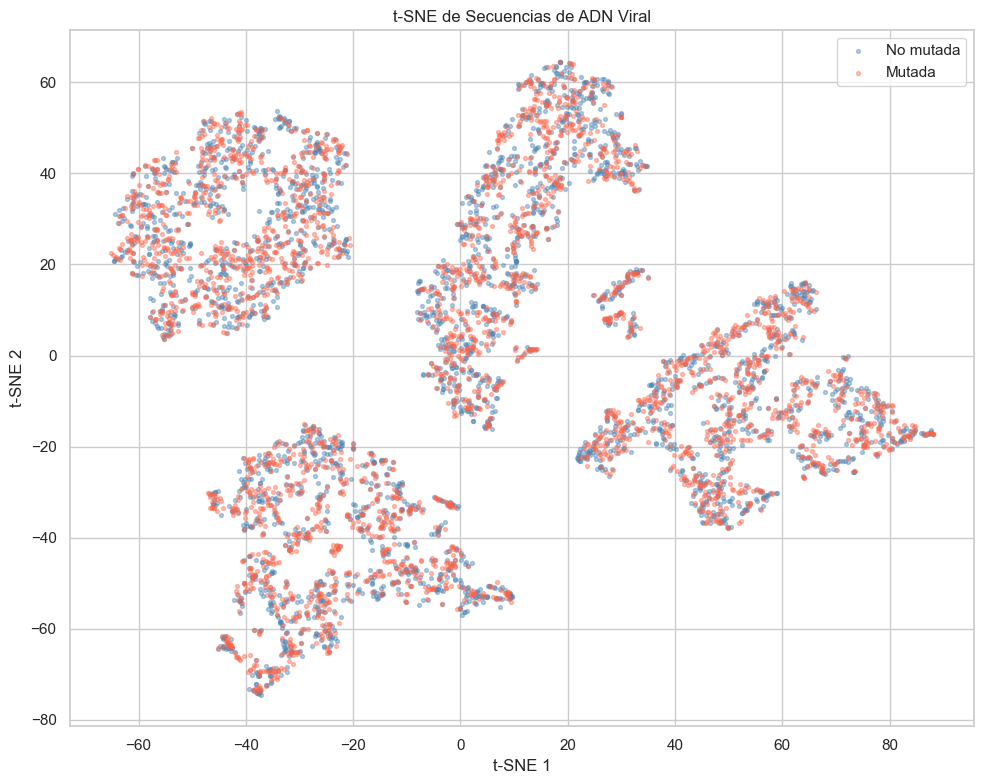

In [31]:
np.random.seed(42)

# Muestra estratificada
idx0, idx1 = np.where(y_full==0)[0], np.where(y_full==1)[0]
n = min(3000, len(idx0), len(idx1))
sample_idx = np.r_[np.random.choice(idx0,n,False), np.random.choice(idx1,n,False)]
y_sample = y_full[sample_idx]

# Reducción dimensional
X_svd = TruncatedSVD(50, random_state=42).fit_transform(X_full_sparse[sample_idx])
X_tsne = TSNE(n_components=2, perplexity=40, learning_rate=200,
              max_iter=1000, random_state=42, n_jobs=-1).fit_transform(X_svd)

# Plot
fig, ax = plt.subplots(figsize=(10,8))
for c,color,label in [(0,'steelblue','No mutada'),(1,'tomato','Mutada')]:
    m = y_sample==c
    ax.scatter(X_tsne[m,0], X_tsne[m,1], c=color, label=label, alpha=0.4, s=8)

ax.set(title='t-SNE de Secuencias de ADN Viral', xlabel='t-SNE 1', ylabel='t-SNE 2')
ax.legend()
plt.tight_layout(); plt.show()

# 5. Experimentación con Modelos Base

Con una buena representación vectorial, se entrenaron varios modelos clásicos de forma individual, cada uno con búsqueda de hiperparámetros: XGBoost (2 configuraciones), LightGBM, Random Forest, SVM y Regresión Logística.

Los modelos individuales obtuvieron resultados aceptables. Sin embargo, motivados por mejorar el puntaje en la competencia, se exploró cómo combinarlos. Se llegó a stacking: una técnica que combina las predicciones de múltiples modelos entrenados para obtener lo mejor de cada uno.

En un primer intento se usó votación: la clase que más modelos predijeron era la ganadora. Sin embargo, esto trata a todos los modelos como iguales sin importar su desempeño. Se buscó una alternativa mejor: entrenar un modelo simple que reciba las predicciones de cada modelo base junto con los targets reales, y que aprenda por sí solo qué peso óptimo darle a cada uno. Para esto se usaron dos meta-modelos, XGBoost y Regresión Logística, y sus predicciones se promedian para obtener la predicción final.

Para entrenar los meta-modelos sin data leakage se usó K-Fold cross-validation con predicciones OOF: cada predicción que entra al meta-modelo proviene de un modelo que nunca vio ese dato.

Los hiperparámetros específicos que aparecen en los modelos base y en los meta-modelos no son arbitrarios: son el resultado de experimentos individuales previos con búsqueda de hiperparámetros (Optuna), que incluso produjeron los primeros envíos a la competencia. Dado que estos modelos ya mostraban buenos resultados de forma individual, la siguiente apuesta natural fue combinarlos mediante stacking.

En una primera versión de stacking, los meta-modelos recibían únicamente las 5 probabilidades de los modelos base junto con el target real. Este enfoque produjo una métrica cercana a 0.805. Para mejorar este resultado, se decidió enriquecer la entrada de los meta-modelos con una representación compacta del espacio de features original. La matriz de features de entrada a los modelos base tiene 3,680 dimensiones (vocabulario TF-IDF efectivo + 11 features biológicos + 1 label encoding). Se aplicó TruncatedSVD para reducirla a 80 componentes, conservando el 99.1% de la varianza explicada. Esta representación comprimida se concatenó con las 5 probabilidades de los modelos base, dando lugar a un vector de entrada de 85 features para los meta-modelos, lo que resultó en una mejora significativa del rendimiento.

# 6. Justificación del Número de Componentes PCA

Se usó TruncatedSVD sobre la matriz de features. Para decidir cuántos componentes conservar, se graficó la varianza explicada acumulada. Se eligieron 80 componentes, que explican el 99.1% de la varianza con ganancia marginal prácticamente nula a partir de ese punto.


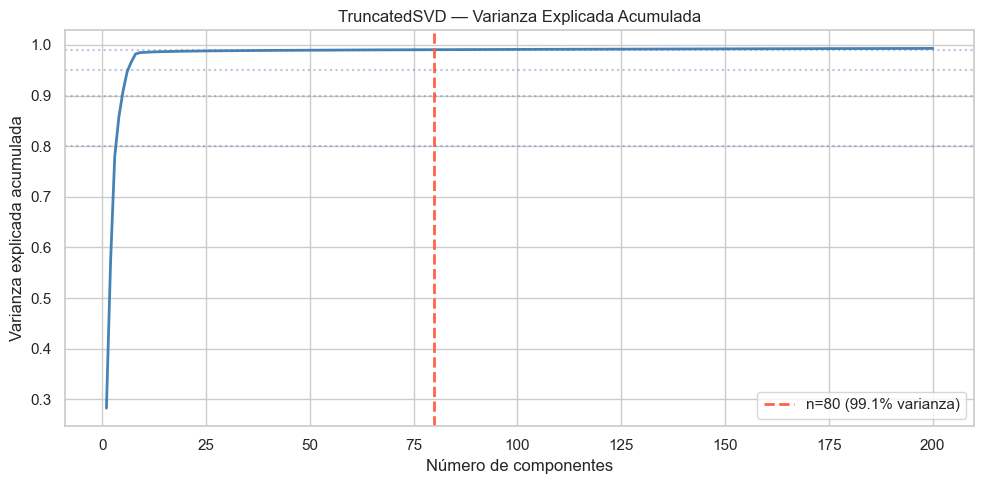

SVD: (46674, 3680) → (46674, 80)


In [32]:
svd_tmp    = TruncatedSVD(n_components=200, random_state=42).fit(X_full_sparse)
cumsum_var = np.cumsum(svd_tmp.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 201), cumsum_var, lw=2, color='steelblue')
ax.axvline(N_SVD, color='tomato', linestyle='--', lw=2, label=f'n={N_SVD} ({cumsum_var[N_SVD-1]*100:.1f}% varianza)')
for t in [0.80, 0.90, 0.95, 0.99]:
    ax.axhline(t, ls=':', alpha=0.4)
ax.set(xlabel='Número de componentes', ylabel='Varianza explicada acumulada',
       title='TruncatedSVD — Varianza Explicada Acumulada')
ax.legend(); plt.tight_layout(); plt.show()

svd         = TruncatedSVD(n_components=N_SVD, random_state=42).fit(X_full_sparse)
X_svd_train = svd.transform(X_full_sparse).astype(np.float32)
X_svd_eval  = svd.transform(X_eval_sparse).astype(np.float32)
print(f"SVD: {X_full_sparse.shape} → {X_svd_train.shape}")


# 7. Búsqueda del Umbral Óptimo

Los clasificadores producen probabilidades entre 0 y 1. El umbral por defecto es 0.5, pero dado que la métrica de evaluación es F1, se buscó el umbral óptimo sobre las predicciones OOF del meta-ensemble. La curva F1 vs umbral y la ROC se muestran en cada experimento.


## 8. Experimento 1 — Pipeline con 1 Semilla (F1 = 0.83 public score)

Implementa la arquitectura completa con una única semilla (seed=123). Sirve como validación del método antes de reducir varianza con múltiples semillas.

Pipeline:
1. `DNAFeatureTransformer` — TF-IDF k-mers(3-5) + 11 bio-features + label encoding
2. 5 base models con K-Fold OOF (5 folds)
3. `TruncatedSVD(80)` sobre features originales
4. Input meta-modelos: [OOF probs (5) + SVD features (80)] = 85 features
5. Meta-LR + Meta-XGB → promedio → búsqueda de umbral óptimo


La siguiente tabla expone los hiperparámetros utilizados por los *modelos base* durante el entrenamiento. Estos valores no fueron asignados manualmente, sino que se obtuvieron mediante un proceso de Optimización de Hiperparámetros (Optuna) en experimentos individuales previos.

| Modelo | Hiperparámetros |
|--------|----------------|
| `xgb_optuna` | `n_estimators` = 1500, `max_depth` = 4, `learning_rate` = 0.06587, `subsample` = 0.8231, `colsample_bytree` = 0.5277, `gamma` = 0.0611, `reg_lambda` = 0.0822, `reg_alpha` = 0.0061, `min_child_weight` = 4, `tree_method` = hist |
| `xgb_v18` | `n_estimators` = 651, `learning_rate` = 0.05, `max_depth` = 6, `subsample` = 0.8, `colsample_bytree` = 0.5, `min_child_weight` = 5, `reg_alpha` = 0.1, `reg_lambda` = 1.0, `tree_method` = hist |
| `rf` | `n_estimators` = 300, `min_samples_leaf` = 2 |
| `lr` | `C` = 10, `max_iter` = 2000, `solver` = lbfgs |
| `svm` | `LinearSVC` con `C` = 1.0, `max_iter` = 2000, calibrado con sigmoid |

In [33]:
SEED_1 = 123

def get_base_models(seed):
    return {
        'xgb_optuna': XGBClassifier(
            n_estimators=1500, max_depth=4,
            learning_rate=0.06586890834463051,
            subsample=0.8231447071825106,
            colsample_bytree=0.5277149233335341,
            gamma=0.06108898389713842,
            reg_lambda=0.08220759629770905,
            reg_alpha=0.006052737357073629,
            min_child_weight=4, tree_method='hist',
            n_jobs=-1, random_state=seed, verbosity=0,
        ),
        'xgb_v18': XGBClassifier(
            n_estimators=651, learning_rate=0.05,
            max_depth=6, subsample=0.8, colsample_bytree=0.5,
            min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
            tree_method='hist', n_jobs=-1, random_state=seed, verbosity=0,
        ),
        'rf':  RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                       n_jobs=-1, random_state=seed),
        'lr':  LogisticRegression(max_iter=2000, C=10, solver='lbfgs',
                                   random_state=seed, n_jobs=-1),
        'svm': CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=seed),
                                       cv=3, method='sigmoid'),
    }

MODEL_NAMES = list(get_base_models(42).keys())


Entrenamiento OOF con 5 folds para la semilla 123. Al finalizar, se entrenan los modelos finales sobre el 100% del train para ser usados con evaluaciones reales (eval.csv de kaggle) y asi obtener el mejor modelo posible. 

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED_1)
oof_probs_1seed = np.zeros((len(full_train), len(MODEL_NAMES)), dtype=np.float32)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_full_sparse, y_full), 1):
    print(f"  Fold {fold}/{N_FOLDS}", flush=True)
    X_tr, X_val = X_full_sparse[tr_idx], X_full_sparse[val_idx]
    for j, (_, m) in enumerate(get_base_models(SEED_1).items()):
        m.fit(X_tr, y_full[tr_idx])
        oof_probs_1seed[val_idx, j] = m.predict_proba(X_val)[:, 1]

final_models_1seed = get_base_models(SEED_1)
for _, m in final_models_1seed.items():
    m.fit(X_full_sparse, y_full)
print("OOF 1 semilla completado.")


  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
OOF 1 semilla completado.


La siguiente tabla expone los hiperparametros utilizados por los *meta-models* durante el entrenamiento. Estos valores no fueron asignados manualmente, sino que se obtuvieron mediante un proceso de Optimización de Hiperparámetros.

| Modelo | Hiperparámetros |
|--------|----------------|
| `meta_lr_1seed` | `C` = 11.9311, `max_iter` = 3000, `solver` = lbfgs, `random_state` = 42 |
| `meta_xgb_1seed` | `n_estimators` = 575, `max_depth` = 4, `learning_rate` = 0.09108, `subsample` = 0.9755, `colsample_bytree` = 0.9287, `reg_lambda` = 3.9788, `tree_method` = hist, `random_state` = 42 |
 

In [35]:
X_meta_train_1seed = np.hstack([oof_probs_1seed, X_svd_train])

meta_lr_1seed = LogisticRegression(C=18.58449698952964, max_iter=3000, solver='lbfgs', random_state=42)
meta_lr_1seed.fit(X_meta_train_1seed, y_full)

meta_xgb_1seed = XGBClassifier(
    n_estimators=575, max_depth=4, lr=0.09108203856867698,
    subsample=0.9755360480279148, colsample_bytree=0.9287449860483958,
    reg_lambda=3.9788026321132417,
    tree_method='hist', n_jobs=-1, random_state=42, verbosity=0,
)
meta_xgb_1seed.fit(X_meta_train_1seed, y_full)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9287449860483958
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Predicciones OOF de los meta-modelos, búsqueda del umbral óptimo por F1, métricas de validación y guardado del pipeline.

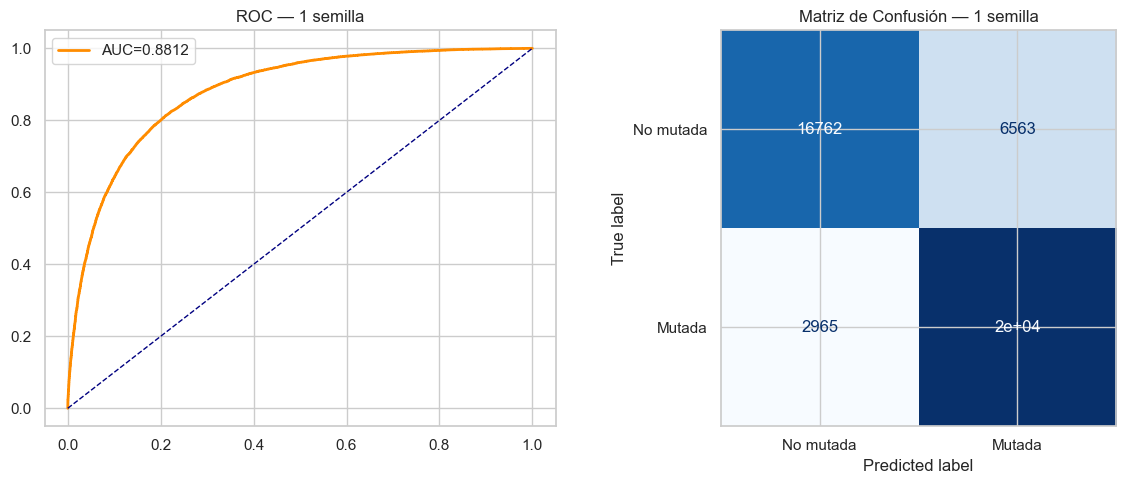

              precision    recall  f1-score   support

   No mutada       0.85      0.72      0.78     23325
      Mutada       0.76      0.87      0.81     23349

    accuracy                           0.80     46674
   macro avg       0.80      0.80      0.79     46674
weighted avg       0.80      0.80      0.79     46674

OOF F1=0.8106  ROC-AUC=0.8812  Threshold=0.405
Guardado -> stacking_5_pca_1_seed_f.joblib


<Response [200]>

In [ ]:
oof_meta_lr_1  = cross_val_predict(meta_lr_1seed,  X_meta_train_1seed, y_full, cv=5, method='predict_proba')[:, 1]
oof_meta_xgb_1 = cross_val_predict(meta_xgb_1seed, X_meta_train_1seed, y_full, cv=5, method='predict_proba')[:, 1]
oof_meta_avg_1 = (oof_meta_lr_1 + oof_meta_xgb_1) / 2.0

best_t_1, best_f_1 = 0.5, 0.0
for t in np.arange(0.25, 0.75, 0.005):
    f = f1_score(y_full, (oof_meta_avg_1 > t).astype(int))
    if f > best_f_1: best_f_1, best_t_1 = f, t

fpr_1, tpr_1, _ = roc_curve(y_full, oof_meta_avg_1)
roc_auc_1 = auc(fpr_1, tpr_1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr_1, tpr_1, color='darkorange', lw=2, label=f'AUC={roc_auc_1:.4f}')
axes[0].plot([0,1],[0,1],'navy',lw=1,ls='--'); axes[0].set(title='ROC — 1 semilla'); axes[0].legend()
cm_1 = confusion_matrix(y_full, (oof_meta_avg_1 > best_t_1).astype(int))
ConfusionMatrixDisplay(cm_1, display_labels=['No mutada','Mutada']).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión — 1 semilla')
plt.tight_layout(); plt.show()

print(classification_report(y_full, (oof_meta_avg_1 > best_t_1).astype(int), target_names=['No mutada','Mutada']))

joblib.dump({
    'feat_transformer': feat_transformer, 'svd': svd,
    'base_models': {SEED_1: final_models_1seed},
    'meta_lr': meta_lr_1seed, 'meta_xgb': meta_xgb_1seed,
    'threshold': best_t_1, 'seeds': [SEED_1], 'n_svd': N_SVD,
    'model_names': MODEL_NAMES, 'oof_f1': best_f_1, 'roc_auc': roc_auc_1,
}, f'{MODELS_DIR}/stacking_5_pca_1_seed_f.joblib')
print(f"OOF F1={best_f_1:.4f}  ROC-AUC={roc_auc_1:.4f}  Threshold={best_t_1:.3f}")
print("Guardado -> stacking_5_pca_1_seed_f.joblib")

## 9. Experimento 2 — Pipeline con 3 Semilla (F1 = 0.85 public score)

Mismo pipeline que el experimento anterior, repetido con 3 semillas distintas (42, 7, 123). Las predicciones OOF se promedian entre semillas para reducir varianza. Los modelos finales también se promedian al predecir sobre eval.


In [37]:
all_oof, all_final = {}, {}

for seed in SEEDS:
    print(f"SEED {seed}")
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    oof = np.zeros((len(full_train), len(MODEL_NAMES)), dtype=np.float32)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_full_sparse, y_full), 1):
        print(f"  Fold {fold}/{N_FOLDS}", flush=True)
        X_tr, X_val = X_full_sparse[tr_idx], X_full_sparse[val_idx]
        for j, (_, m) in enumerate(get_base_models(seed).items()):
            m.fit(X_tr, y_full[tr_idx])
            oof[val_idx, j] = m.predict_proba(X_val)[:, 1]

    final_models = get_base_models(seed)
    for name, m in final_models.items():
        m.fit(X_full_sparse, y_full)

    all_oof[seed], all_final[seed] = oof, final_models

print("OOF 3 semillas completado.")


SEED 42
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
SEED 7
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
SEED 123
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
OOF 3 semillas completado.


Se promedian las predicciones OOF de las 3 semillas y se entrenan los meta-modelos con los hiperparámetros obtenidos previamente.

In [38]:
oof_avg_3seeds      = np.mean([all_oof[s] for s in SEEDS], axis=0)
X_meta_train_3seeds = np.hstack([oof_avg_3seeds, X_svd_train])

meta_lr_3seeds = LogisticRegression(C=11.931107771040288, max_iter=3000, solver='lbfgs', random_state=42)
meta_lr_3seeds.fit(X_meta_train_3seeds, y_full)

meta_xgb_3seeds = XGBClassifier(
    n_estimators=550, max_depth=5, lr=0.09172072655055472,
    subsample=0.7627449357708019, colsample_bytree=0.8895334938541403,
    reg_lambda=0.12396323514588216,
    tree_method='hist', n_jobs=-1, random_state=42, verbosity=0,
)
meta_xgb_3seeds.fit(X_meta_train_3seeds, y_full)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8895334938541403
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Predicciones OOF de los meta-modelos (3 semillas), búsqueda del umbral óptimo, métricas de validación y guardado del pipeline.

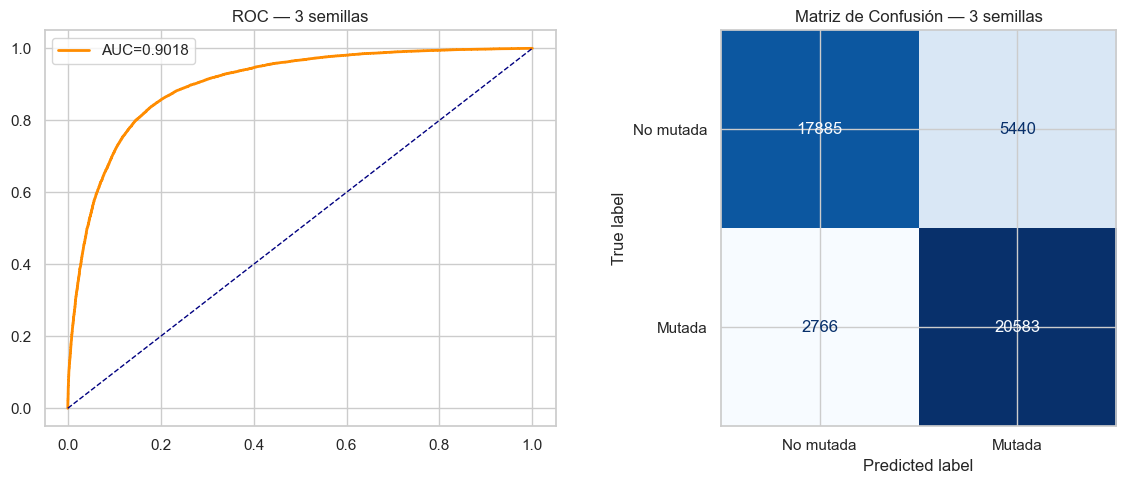

              precision    recall  f1-score   support

   No mutada       0.87      0.77      0.81     23325
      Mutada       0.79      0.88      0.83     23349

    accuracy                           0.82     46674
   macro avg       0.83      0.82      0.82     46674
weighted avg       0.83      0.82      0.82     46674

OOF F1=0.8338  ROC-AUC=0.9018  Threshold=0.410
Guardado -> stacking_5_pca_3_seed_f.joblib


In [39]:
oof_meta_lr_3  = cross_val_predict(meta_lr_3seeds,  X_meta_train_3seeds, y_full, cv=5, method='predict_proba')[:, 1]
oof_meta_xgb_3 = cross_val_predict(meta_xgb_3seeds, X_meta_train_3seeds, y_full, cv=5, method='predict_proba')[:, 1]
oof_meta_avg_3 = (oof_meta_lr_3 + oof_meta_xgb_3) / 2.0

best_t_3, best_f_3 = 0.5, 0.0
for t in np.arange(0.25, 0.75, 0.005):
    f = f1_score(y_full, (oof_meta_avg_3 > t).astype(int))
    if f > best_f_3: best_f_3, best_t_3 = f, t

fpr_3, tpr_3, _ = roc_curve(y_full, oof_meta_avg_3)
roc_auc_3 = auc(fpr_3, tpr_3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr_3, tpr_3, color='darkorange', lw=2, label=f'AUC={roc_auc_3:.4f}')
axes[0].plot([0,1],[0,1],'navy',lw=1,ls='--'); axes[0].set(title='ROC — 3 semillas'); axes[0].legend()
cm_3 = confusion_matrix(y_full, (oof_meta_avg_3 > best_t_3).astype(int))
ConfusionMatrixDisplay(cm_3, display_labels=['No mutada','Mutada']).plot(ax=axes[2-1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión — 3 semillas')
plt.tight_layout(); plt.show()

print(classification_report(y_full, (oof_meta_avg_3 > best_t_3).astype(int), target_names=['No mutada','Mutada']))

joblib.dump({
    'feat_transformer': feat_transformer, 'svd': svd,
    'base_models': {s: all_final[s] for s in SEEDS},
    'meta_lr': meta_lr_3seeds, 'meta_xgb': meta_xgb_3seeds,
    'threshold': best_t_3, 'seeds': SEEDS, 'n_svd': N_SVD,
    'model_names': MODEL_NAMES, 'oof_f1': best_f_3, 'roc_auc': roc_auc_3,
}, f'{MODELS_DIR}/stacking_5_pca_3_seed_f.joblib')
print(f"OOF F1={best_f_3:.4f}  ROC-AUC={roc_auc_3:.4f}  Threshold={best_t_3:.3f}")
print("Guardado -> stacking_5_pca_3_seed_f.joblib")

## 10. Resultados y Generación de Submissions

Se cargan los pipelines guardados y se generan las predicciones finales para el conjunto de evaluación.

| Modelo | Seeds | Threshold | Public Score Kaggle |
|--------|-------|-----------|---------------------|
| `stacking_5_pca_1_seed` | 1 (123) | 0.405 | 0.83 |
| `stacking_5_pca_3_seed` | 3 (42, 7, 123) | 0.410 | 0.85 |

Los umbrales de decisión (0.405 y 0.410) fueron determinados durante la experimentación: en cada experimento se buscó el valor que maximizaba el F1 sobre las predicciones OOF. Una vez identificados, se fijaron de forma explícita en el código para poder reproducir las predicciones sobre el conjunto de evaluación sin necesidad de re-entrenar.


In [ ]:
import os, math, joblib, numpy as np, pandas as pd, scipy.sparse as sp
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, RobustScaler
import warnings
warnings.filterwarnings('ignore')


class DNAFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, max_features=30000):
        self.max_features = max_features
    def fit(self, X, y=None):
        self.tfidf_ = TfidfVectorizer(
            analyzer='char', ngram_range=(3, 5),
            lowercase=False, sublinear_tf=True,
            min_df=2, max_features=self.max_features,
        )
        self.tfidf_.fit(X['sequence'])
        self.le_ = LabelEncoder()
        self.le_.fit(X['original_label'])
        self.scaler_ = RobustScaler(quantile_range=(10.0, 90.0))
        self.scaler_.fit(self._bio(X['sequence'].values))
        return self
    def transform(self, X, y=None):
        X_tfidf = self.tfidf_.transform(X['sequence'])
        labels  = X['original_label'].values
        known   = set(self.le_.classes_)
        safe    = np.array([l if l in known else self.le_.classes_[0] for l in labels])
        lenc    = self.le_.transform(safe).reshape(-1, 1)
        bio     = self.scaler_.transform(self._bio(X['sequence'].values))
        num     = sp.csr_matrix(np.hstack([bio, lenc]))
        return sp.hstack([X_tfidf, num]).astype(np.float32)
    @staticmethod
    def _bio(sequences):
        out = np.empty((len(sequences), 11), dtype=np.float32)
        for i, seq in enumerate(sequences):
            seq = str(seq).upper(); n = len(seq)
            if n == 0: out[i] = 0.0; continue
            cA=seq.count('A'); cC=seq.count('C'); cG=seq.count('G'); cT=seq.count('T')
            inv=1.0/n; af,cf,gf,tf_=cA*inv,cC*inv,cG*inv,cT*inv
            gc=(cG+cC)*inv; pur=(cA+cG)*inv; cg_freq=seq.count('CG')/max(1,n-1)
            entropy=sum(-p*math.log2(p) for p in (af,cf,gf,tf_) if p>0)
            out[i]=(n,gc,af,tf_,gf,cf,pur,cg_freq,entropy,float(len(set(seq))),
                    1.0 if (cA+cC+cG+cT)<n else 0.0)
        return out

def predict_with_bundle(bundle, df_new, threshold):
    X_sp   = bundle['feat_transformer'].transform(df_new)
    X_svd  = bundle['svd'].transform(X_sp).astype(np.float32)
    probs  = [np.mean([bundle['base_models'][s][n].predict_proba(X_sp)[:,1]
                       for s in bundle['seeds']], axis=0) for n in bundle['model_names']]
    X_meta = np.hstack([np.column_stack(probs), X_svd])
    proba  = (bundle['meta_lr'].predict_proba(X_meta)[:,1] +
              bundle['meta_xgb'].predict_proba(X_meta)[:,1]) / 2.0
    return (proba > threshold).astype(int)

MODELS_DIR  = "models_f"
kaggle_eval = pd.read_csv("../Data/eval.csv")

submissions = [
    ('1 semilla',  f'{MODELS_DIR}/stacking_5_pca_1_seed_f.joblib',  'submission_final_exp_1_seed_f_real.csv',  0.405),
    ('3 semillas', f'{MODELS_DIR}/stacking_5_pca_3_seed_f.joblib',  'submission_final_exp_3_seeds_f_real.csv', 0.410),
]

for name, fpath, csv_name, threshold in submissions:

    bundle = joblib.load(fpath)

    print("Realizando predicciones, por favor espere")

    pred   = predict_with_bundle(bundle, kaggle_eval, threshold)
    sub    = pd.DataFrame({'id': kaggle_eval['id'], 'is_mutated': pred})
    sub.to_csv(f'{MODELS_DIR}/{csv_name}', index=False)
    print(f"{name} (threshold={threshold}) -> {csv_name}")
    print(sub['is_mutated'].value_counts().to_dict())


Realizando predicciones, por favor espere
1 semilla (threshold=0.405) -> submission_final_exp_f_real.csv
{1: 2996, 0: 2190}
Realizando predicciones, por favor espere
3 semillas (threshold=0.41) -> submission_final_exp_3_seeds_f_real.csv
{1: 2880, 0: 2306}
